# Comparison expression of promoters across growth conditions.

In [17]:
import numpy as np
import pandas as pd
from numba import njit

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from matplotlib.gridspec import GridSpec

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import glob as glob
import itertools

Import metadata for growth conditions.

In [2]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
df_gc.tail(5)

,Index,Condition,Description,Group
34,37,low phosphate,M9 Minimal Media with 0.5% Glucose to steady s...,Nutrient–mineral limitation
35,38,copper sulfate (2mM),M9 Minimal Media with 0.5% Glucose to steady s...,Metal & membrane stress
36,39,acetate,M9 Minimal Media with 0.5% Sodium Acetate,Carbon‐source
37,40,nitrate,M9 Minimal Media with 0.5% Glucose with 80mM P...,Osmotic & ionic stress
38,41,anaerobic + nitrate,M9 Minimal Media with 0.5% Glucose grown compl...,Anaerobic


Import mapping of barcodes to promoter variants.

In [3]:
df_map = pd.read_csv("../../data/mapping/mapped_barcodes_filtered.csv")

Import wild type sequence for each promoter.

In [4]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
114,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
115,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
116,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
117,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


Import barcode counts.

In [5]:
files = np.hstack([glob.glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]
inds[0:5]

[np.str_('1-1'),
 np.str_('1-2'),
 np.str_('10-1'),
 np.str_('10-2'),
 np.str_('11-1')]

For each condition, we import all promoters and get DNA and RNA counts.

In [6]:
def get_counts(gc):
    ind = gc

    file_DNA = glob.glob(f"../../data/extracted_barcodes/{ind}*DNA*.txt")[0]
    df_DNA = pd.read_csv(
        file_DNA, 
        names=['ct_0', 'barcode'], sep="\\s+")
    file_RNA = glob.glob(f"../../data/extracted_barcodes/{ind}*RNA*.txt")[0]
    df_RNA = pd.read_csv(
        file_RNA, 
        names=['ct_1', 'barcode'], sep="\\s+")

    df_counts = df_DNA.merge(df_RNA, on="barcode", how='outer').fillna(0)
    df_counts = df_counts.merge(df_map, on="barcode", how='inner')
    return df_counts

With the counts in hand we can compute relative expression values for all promoters in a condition. For that, we compute the abundance of DNA counts belonging to a certain promoter relative to the rest of the library, to control for variation in number of reads across different experiments. We then compute the same for all RNA counts, and then compute relative expression as ratio of normalized DNA and RNA counts.

In [7]:
def get_expression_all(gc):
    df_counts = get_counts(gc)
    df = pd.DataFrame()
    promoter_list = []
    A_list = []
    for promoter, gdf in df_counts.groupby('promoter'):
        dna = gdf['ct_0'].sum() / df_counts['ct_0'].sum()
        rna = gdf['ct_1'].sum() / df_counts['ct_1'].sum()
        A_list.append(rna/dna)
        promoter_list.append(promoter)

    return pd.DataFrame(data={'promoter': promoter_list, 'A': A_list, 'gc': gc})

This function is now getting applied to each growth condition and concatenated into one big dataframe.

In [8]:
df_list = [get_expression_all(x) for x in inds]
df = pd.concat(df_list)

# filter out two promoters
df = df[[x not in ['galEp', 'ybeDp2'] for x in df['promoter']]]

/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_2507/3709201523.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  A_list.append(rna/dna)


To find which condition is standing out compared to the others for each promoter, we compute the fold change for each condition relative to the median across all conditions.

In [9]:
df_list_norm = []
for _, gdf in df.groupby('promoter'):
    gdf['A_norm'] = gdf['A'] / np.median(gdf['A'])
    df_list_norm.append(gdf)

df_norm = pd.concat(df_list_norm)
df_norm

,promoter,A,gc,A_norm
0,TSS_1414_storz_regulondb,0.784440,1-1,1.026682
0,TSS_1414_storz_regulondb,0.788393,1-2,1.031855
0,TSS_1414_storz_regulondb,0.767066,10-1,1.003942
0,TSS_1414_storz_regulondb,0.783145,10-2,1.024987
0,TSS_1414_storz_regulondb,0.782790,11-1,1.024523
...,...,...,...,...
113,znuCp,1.076249,7-2,0.665788
113,znuCp,1.484661,8-1,0.918439
113,znuCp,1.140904,8-2,0.705784
113,znuCp,2.494817,9-1,1.543340


There are some promoters with cryptic labels, so we relabel them.

In [14]:
tss_names = {
    "TSS_1414_storz_regulondb": 'yahM',
    'TSS_18061_regulondb': 'yjjJ',
    'TSS_4654_wanner_regulondb': 'ymfJ',
    'TSS_4655_regulondb': 'ymfJ_2',
    'TSS_6311_regulondb': 'dicA',
}

Let's build a function that extracts the short description from the index for each growth condition.

In [13]:
def x_label_names(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}, rep {x.split('-')[1]}"

Now we can plot the fold change in expression for each promoter. We also do some hierarchical clustering for better visualition of the matrix.

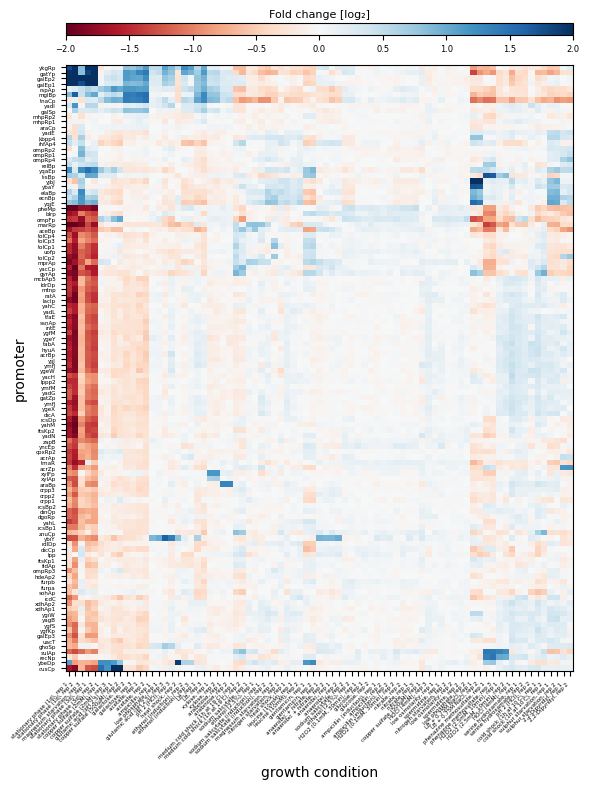

In [ ]:
# compute log of fold change
df_norm['log_A'] = np.log2(df_norm['A_norm'])

# reshape dataframe
pivot_df = df_norm.pivot(index='promoter', columns='gc', values='log_A')

# Perform hierarchical clustering on rows (promoters)
row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)

# Perform hierarchical clustering on columns (gc)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Simple clustered heatmap without dendrograms
fig, ax = plt.subplots(figsize=(6, 8))

# Create pcolormesh of clustered data
im = ax.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set labels
labels = [x_label_names(x) for x in clustered_df.columns]
ax.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, labels , fontsize=4, rotation=45, ha='right')


labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
labels = [x.split('_')[0] for x in labels]
ax.set_yticks(np.arange(len(clustered_df.index)) + 0.5, labels, fontsize=4,)

ax.set_xlabel('growth condition')
ax.set_ylabel('promoter')

# Add colorbar
# Create horizontal colorbar at the top
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="2%", pad=0.3)  # size controls height
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Fold change [log₂]', fontsize=8)
cbar.ax.tick_params(labelsize=6)

# Move the label to the top
cbar.ax.xaxis.set_label_position('top')
ax.grid(False)
plt.grid(False)
plt.tight_layout()

#fig.savefig('expression_shift_global_SI.pdf')

Next we make a summarized version where we compute the mean of the replicates for each condition.

['stationary phase (1d)', 'stationary phase (3d)', 'acetate', 'galactose', 'glutamic acid (pH 2.5)', 'copper sulfate (500µM)', 'copper sulfate (2mM)', 'xylose', 'arabinose', 'LB', 'ethanol (induction)', 'LB + 0.75M NaCl', 'magnesium starvation', 'phenazine methosulfate', 'H2O2 (2.5mM, 10min)', 'cold shock (1h at 10 C)', 'HOCl (4mM)', 'serine hydroxamate', 'sodium salicytate (induction)', 'heat shock', 'leucine (10mM)', 'sulphur starvation', '2,2-Dipyridyl', 'gentamicin', 'medium cold shock (1h at 19 C)', 'ampicillin', 'low phosphate', 'spermidine', 'low osmolarity', 'glucose', 'ampicillin (induction)', 'H2O2 (0.1mM, 30min)', 'nitrate', 'nitrogen starvation', 'sodium salicytate', 'ethanol (2.5%)', 'pH 2 (HCl)', 'anaerobic', 'anaerobic + nitrate']


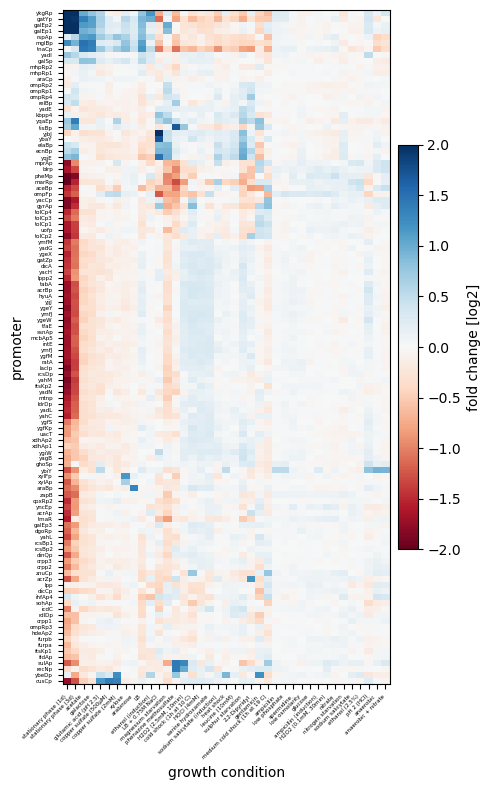

In [16]:
def x_label_names2(x):
    
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

df_norm['log_A'] = np.log2(df_norm['A_norm'])
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
_df = df_norm.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()

pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)

# Perform hierarchical clustering on columns (gc)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Simple clustered heatmap without dendrograms
fig, ax = plt.subplots(figsize=(5, 8))

# Create pcolormesh of clustered data
im = ax.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set labels
labels = [x_label_names2(x) for x in clustered_df.columns]
print(labels)
ax.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, labels , fontsize=4, rotation=45, ha='right')


labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
labels = [x.split('_')[0] for x in labels]
ax.set_yticks(np.arange(len(clustered_df.index)) + 0.5, labels, fontsize=4,)

ax.set_xlabel('growth condition')
ax.set_ylabel('promoter')

# Add colorbar
plt.colorbar(im, ax=ax, label='fold change [log2]', shrink=0.6, pad=0.02)
ax.grid(False)
plt.grid(False)
plt.tight_layout()

#fig.savefig('expression_shift_global.pdf')

Finally, we add another subplot that shows the median of relative expression for each promoter, to show if the promoter is expressing on a high or low level in general.

/var/folders/67/2rd1gct91876bvjs_7ny9rcw0000gn/T/ipykernel_65770/3799108337.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


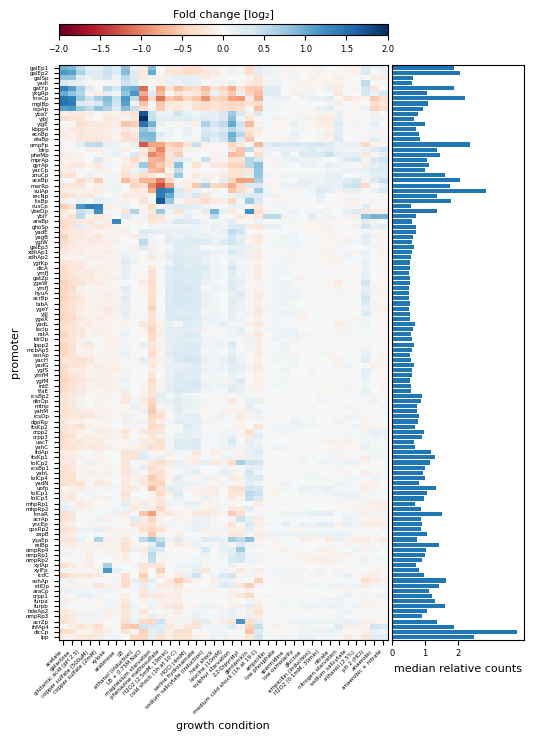

In [30]:
def x_label_names2(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

#df_norm['log_A'] = np.log2(df_norm['A_f'])
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
_df = df_norm[[x not in ['7-1', '7-2', '8-1', '8-2'] for x in df_norm['gc'].values]]
_df = _df.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()
pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

# Hierarchical clustering
row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Prepare data for bar plot - reorder to match heatmap
df_exp = df_norm.groupby('promoter')['A'].apply('median').reset_index()
df_exp = df_exp.set_index('promoter').loc[clustered_df.index].reset_index()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 8), gridspec_kw={'width_ratios': [5, 2], 'wspace': 0.02})

# Left panel: Heatmap
im = ax1.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set heatmap labels
x_labels = [x_label_names2(x) for x in clustered_df.columns]
ax1.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, x_labels, fontsize=4, rotation=45, ha='right')
y_labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
y_labels = [x.split('_')[0] for x in y_labels]
ax1.set_yticks(np.arange(len(clustered_df.index)) + 0.5, y_labels, fontsize=4)
ax1.set_xlabel('growth condition', fontsize=8)
ax1.set_ylabel('promoter', fontsize=8)
ax1.invert_yaxis()
ax1.grid(False)

# Create horizontal colorbar at the top of heatmap
divider = make_axes_locatable(ax1)
cax = divider.append_axes("top", size="2%", pad=0.3)
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Fold change [log₂]', fontsize=8)
cbar.ax.tick_params(labelsize=6)
cbar.ax.xaxis.set_label_position('top')

# Create dummy axes above right panel to match colorbar space
divider2 = make_axes_locatable(ax2)
dummy_cax = divider2.append_axes("top", size="2%", pad=0.3)
dummy_cax.axis('off')  # Hide the dummy axes

# Right panel: Bar plot
ax2.barh(np.arange(len(df_exp)), df_exp['A'])
bar_labels = [tss_names[x] if x in tss_names.keys() else x for x in df_exp.promoter]
bar_labels = [x.split('_')[0] for x in bar_labels]
ax2.set_ylim(-0.5, len(df_exp)-0.5)
ax2.invert_yaxis()
ax2.set_yticks([])
ax2.set_xticks([0, 1, 2], [0, 1, 2], fontsize=6)
ax2.set_xlabel("median relative counts", fontsize=8)

# Remove y-axis labels from bar plot since they're redundant with heatmap
#ax2.set_yticklabels([])

plt.tight_layout()
#fig.savefig('expression_shift_global_main.pdf')

We also make a horizontal version of the plot for slides. (transformed with ChatGPT.)

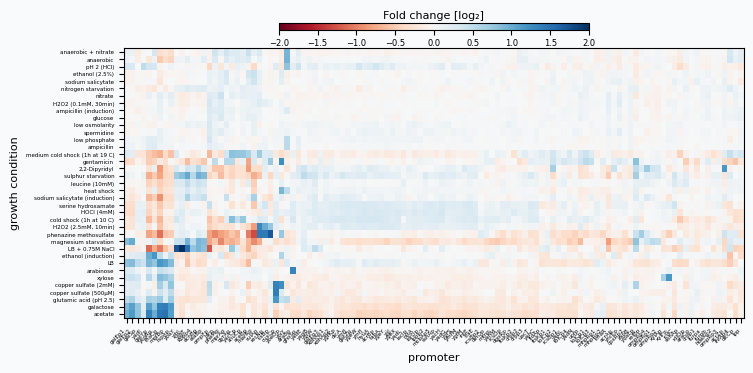

In [18]:



# --- your existing helper ---
def x_label_names2(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

# --- Data processing (unchanged) ---
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
_df = df_norm[[x not in ['7-1', '7-2', '8-1', '8-2'] for x in df_norm['gc'].values]]
_df = _df.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()
pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)
clustered_df = pivot_df.iloc[row_order, col_order]

df_exp = df_norm.groupby('promoter')['A'].apply('median').reset_index()
df_exp = df_exp.set_index('promoter').loc[clustered_df.index].reset_index()

# --- Figure setup ---
fig = plt.figure(figsize=(8, 4), constrained_layout=False)
fig.patch.set_facecolor('#F9FAFB')

# Grid layout: small top for colorbar, large bottom for heatmap
gs = GridSpec(nrows=2, ncols=1, height_ratios=[0.10, 1.0], hspace=0.08, figure=fig)

# --- Heatmap axis ---
ax1 = fig.add_subplot(gs[1])
ax1.set_facecolor('#F9FAFB')

im = ax1.pcolormesh(clustered_df.values.T, cmap='RdBu', vmax=2, vmin=-2)

x_labels = [x_label_names2(x) for x in clustered_df.columns]
ax1.set_yticks(np.arange(len(clustered_df.columns)) + 0.5, x_labels, fontsize=4)
y_labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
y_labels = [x.split('_')[0] for x in y_labels]
ax1.set_xticks(np.arange(len(clustered_df.index)) + 0.5, y_labels, fontsize=4, rotation=45, ha='right')
ax1.set_ylabel('growth condition', fontsize=8)
ax1.set_xlabel('promoter', fontsize=8)
ax1.grid(False)

# --- Colorbar container ---
cbar_container = fig.add_subplot(gs[0])
cbar_container.set_facecolor('#F9FAFB')
cbar_container.set_frame_on(False)
cbar_container.set_xticks([])
cbar_container.set_yticks([])

# --- Centered, slim colorbar ---
width_frac = 0.5    # half-width
height_frac = 0.25  # thin
x0 = (1 - width_frac) / 2
y0 = 0.25           # slightly lower so label sits above cleanly

cax = cbar_container.inset_axes([x0, y0, width_frac, height_frac])
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

# Proper label placement above the bar
cbar.set_label('Fold change [log₂]', fontsize=8, labelpad=3)  # increased labelpad
cbar.ax.tick_params(labelsize=6, pad=3)
cbar.ax.xaxis.set_label_position('top')

# --- Export ---
#fig.savefig("expression_shift_global_main.pdf", facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
